In [30]:
# import standard python libraries
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import os, subprocess

In [31]:
# Import python package for working with cooler files and tools for analysis
import cooler
import cooltools.lib.plotting

In [32]:
from packaging import version
if version.parse(cooltools.__version__) < version.parse('0.5.4'):
    raise AssertionError("tutorials rely on cooltools version 0.5.4 or higher,"+
                         "please check your cooltools version and update to the latest")

In [33]:
### to load a cooler with a specific resolution use the following syntax:
clr_2 = cooler.Cooler("/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/50000")
clr_1 = cooler.Cooler("/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/50000")

In [34]:
import bioframe
bins = clr_1.bins()[:]
hg38_genome = bioframe.load_fasta('/usr/users/papantonis1/aman/microc_project/refgen/hg38.fa');
## note the next command may require installing pysam
gc_cov = bioframe.frac_gc(bins[['chrom', 'start', 'end']], hg38_genome)
gc_cov.to_csv('hg38_gc_cov_100kb.tsv',index=False,sep='\t')
display(gc_cov)

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/bioframe/extras.py:316: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg = df.groupby("chrom", sort=False)[["start", "end"]].apply(_each)


,chrom,start,end,GC
0,chr1,0,50000,0.484250
1,chr1,50000,100000,0.376740
2,chr1,100000,150000,0.429960
3,chr1,150000,200000,0.486340
4,chr1,200000,250000,0.480564
...,...,...,...,...
61771,chrY,57050000,57100000,0.391180
61772,chrY,57100000,57150000,0.397320
61773,chrY,57150000,57200000,0.469440
61774,chrY,57200000,57227415,0.553775


In [35]:
view_df = pd.DataFrame({'chrom': clr_1.chromnames,
                        'start': 0,
                        'end': clr_1.chromsizes.values,
                        'name': clr_1.chromnames}
                      )
display(view_df)

,chrom,start,end,name
0,chr1,0,248956422,chr1
1,chr2,0,242193529,chr2
2,chr3,0,198295559,chr3
3,chr4,0,190214555,chr4
4,chr5,0,181538259,chr5
5,chr6,0,170805979,chr6
6,chr7,0,159345973,chr7
7,chr8,0,145138636,chr8
8,chr9,0,138394717,chr9
9,chr10,0,133797422,chr10


In [36]:
# obtain first 3 eigenvectors
cis_eigs_1 = cooltools.eigs_cis(
                        clr_1,
                        gc_cov,
                        view_df=view_df,
                        n_eigs=3,
                        )

# cis_eigs[0] returns eigenvalues, here we focus on eigenvectors
eigenvector_track_1 = cis_eigs_1[1][['chrom','start','end','E1']]

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):


In [37]:
# obtain first 3 eigenvectors
cis_eigs_2 = cooltools.eigs_cis(
                        clr_1,
                        gc_cov,
                        view_df=view_df,
                        n_eigs=3,
                        )

# cis_eigs[0] returns eigenvalues, here we focus on eigenvectors
eigenvector_track_2 = cis_eigs_2[1][['chrom','start','end','E1']]

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):


In [38]:
# from matplotlib.colors import LogNorm
# from mpl_toolkits.axes_grid1 import make_axes_locatable
# import matplotlib.pyplot as plt
# import numpy as np

# for chrom in clr_1.chromnames:
#     start, end = clr_1.extent(chrom)
#     matrix = clr_1.matrix(balance=True)[start:end, start:end]
#     bins = clr_1.bins()[start:end]
#     e1_values = eigenvector_track.loc[bins.index, 'E1'].values

#     f, ax = plt.subplots(figsize=(15, 10))

#     norm = LogNorm(vmax=0.1)
#     im = ax.matshow(matrix, norm=norm, cmap='fall')
#     plt.axis([0, matrix.shape[0], matrix.shape[1], 0])

#     divider = make_axes_locatable(ax)
#     cax = divider.append_axes("right", size="5%", pad=0.1)
#     plt.colorbar(im, cax=cax, label='corrected frequencies')
#     ax.set_ylabel(f'{chrom}')
#     ax.xaxis.set_visible(False)

#     ax1 = divider.append_axes("top", size="20%", pad=0.25, sharex=ax)
#     ax1.plot([0, matrix.shape[0]], [0, 0], 'k', lw=0.25)
#     ax1.plot(e1_values, label='E1')
#     ax1.set_ylabel('E1')
#     ax1.set_xticks([])

#     plt.show()


#

### Saddleplots

In [39]:
# count cpus
num_cpus = os.getenv('SLURM_CPUS_PER_TASK')
if not num_cpus:
    num_cpus = os.cpu_count()
num_cpus = int(num_cpus)

In [40]:
cvd_1 = cooltools.expected_cis(
        clr=clr_1,
        view_df=view_df,
        nproc=num_cpus
)

####

cvd_2 = cooltools.expected_cis(
        clr=clr_2,
        view_df=view_df,
        nproc=num_cpus
)

INFO:root:creating a Pool of 48 workers


/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
INFO:root:creating a Pool of 48 workers
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))


In [41]:
Q_LO = 0.025 # ignore 2.5% of genomic bins with the lowest E1 values
Q_HI = 0.975 # ignore 2.5% of genomic bins with the highest E1 values
N_GROUPS = 38 # divide remaining 95% of the genome into 38 equisized groups, 2.5% each

In [42]:
interaction_sum_1, interaction_count_1 =  cooltools.saddle(
        clr_1,
        cvd_1,
        eigenvector_track_1,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df
)

####

interaction_sum_2, interaction_count_2 =  cooltools.saddle(
        clr_2,
        cvd_2,
        eigenvector_track_2,
        'cis',
        n_bins=N_GROUPS,
        qrange=(Q_LO,Q_HI),
        view_df=view_df
)

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/api/saddle.py:92: RuntimeWarning: invalid value encountered in divide
  return obs_mat / exp_mat
/usr/users/p

In [43]:
# saddle plot func.

import warnings
from cytoolz import merge

def saddleplot(
    track,
    saddledata,
    n_bins,
    vrange=None,
    qrange=(0.0, 1.0),
    cmap="coolwarm",
    scale="log",
    vmin=0.5,
    vmax=2,
    color=None,
    title=None,
    xlabel=None,
    ylabel=None,
    clabel=None,
    fig=None,
    fig_kws=None,
    heatmap_kws=None,
    margin_kws=None,
    cbar_kws=None,
    subplot_spec=None,
):
    """
    Generate a saddle plot.
    Parameters
    ----------
    track : pd.DataFrame
        See cooltools.digitize() for details.
    saddledata : 2D array-like
        Saddle matrix produced by `make_saddle`. It will include 2 flanking
        rows/columns for outlier signal values, thus the shape should be
        `(n+2, n+2)`.
    cmap : str or matplotlib colormap
        Colormap to use for plotting the saddle heatmap
    scale : str
        Color scaling to use for plotting the saddle heatmap: log or linear
    vmin, vmax : float
        Value limits for coloring the saddle heatmap
    color : matplotlib color value
        Face color for margin bar plots
    fig : matplotlib Figure, optional
        Specified figure to plot on. A new figure is created if none is
        provided.
    fig_kws : dict, optional
        Passed on to `plt.Figure()`
    heatmap_kws : dict, optional
        Passed on to `ax.imshow()`
    margin_kws : dict, optional
        Passed on to `ax.bar()` and `ax.barh()`
    cbar_kws : dict, optional
        Passed on to `plt.colorbar()`
    subplot_spec : GridSpec object
        Specify a subregion of a figure to using a GridSpec.
    Returns
    -------
    Dictionary of axes objects.
    """

#     warnings.warn(
#         "Generating a saddleplot will be deprecated in future versions, "
#         + "please see https://github.com/open2c_examples for examples on how to plot saddles.",
#         DeprecationWarning,
#     )

    from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
    from matplotlib.colors import Normalize, LogNorm
    from matplotlib import ticker
    import matplotlib.pyplot as plt

    class MinOneMaxFormatter(ticker.LogFormatter):
        def set_locs(self, locs=None):
            self._sublabels = set([vmin % 10 * 10, vmax % 10, 1])

        def __call__(self, x, pos=None):
            if x not in [vmin, 1, vmax]:
                return ""
            else:
                return "{x:g}".format(x=x)

    track_value_col = track.columns[3]
    track_values = track[track_value_col].values

    digitized_track, binedges = cooltools.digitize(
        track, n_bins, vrange=vrange, qrange=qrange
    )
    x = digitized_track[digitized_track.columns[3]].values.astype(int).copy()
    x = x[(x > -1) & (x < len(binedges) + 1)]

    # Old version
    # hist = np.bincount(x, minlength=len(binedges) + 1)

    groupmean = track[track.columns[3]].groupby(digitized_track[digitized_track.columns[3]]).mean()

    if qrange is not None:
        lo, hi = qrange
        binedges = np.linspace(lo, hi, n_bins + 1)

    # Barplot of mean values and saddledata are flanked by outlier bins
    n = saddledata.shape[0]
    X, Y = np.meshgrid(binedges, binedges)
    C = saddledata
    if (n - n_bins) == 2:
        C = C[1:-1, 1:-1]
        groupmean = groupmean[1:-1]

    # Layout
    if subplot_spec is not None:
        GridSpec = partial(GridSpecFromSubplotSpec, subplot_spec=subplot_spec)
    grid = {}
    gs = GridSpec(
        nrows=3,
        ncols=3,
        width_ratios=[0.2, 1, 0.1],
        height_ratios=[0.2, 1, 0.1],
        wspace=0.05,
        hspace=0.05,
    )

    # Figure
    if fig is None:
        fig_kws_default = dict(figsize=(5, 5))
        fig_kws = merge(fig_kws_default, fig_kws if fig_kws is not None else {})
        fig = plt.figure(**fig_kws)

    # Heatmap
    if scale == "log":
        norm = LogNorm(vmin=vmin, vmax=vmax)
    elif scale == "linear":
        norm = Normalize(vmin=vmin, vmax=vmax)
    else:
        raise ValueError("Only linear and log color scaling is supported")

    grid["ax_heatmap"] = ax = plt.subplot(gs[4])
    heatmap_kws_default = dict(cmap="coolwarm", rasterized=True)
    heatmap_kws = merge(
        heatmap_kws_default, heatmap_kws if heatmap_kws is not None else {}
    )
    img = ax.pcolormesh(X, Y, C, norm=norm, **heatmap_kws)
    plt.gca().yaxis.set_visible(False)

    # Margins
    margin_kws_default = dict(edgecolor="k", facecolor=color, linewidth=1)
    margin_kws = merge(margin_kws_default, margin_kws if margin_kws is not None else {})
    # left margin hist
    grid["ax_margin_y"] = plt.subplot(gs[3], sharey=grid["ax_heatmap"])

    plt.barh(
        binedges, height=1/len(binedges), width=groupmean, align="edge", **margin_kws
    )

    plt.xlim(plt.xlim()[1], plt.xlim()[0])  # fliplr
    plt.ylim(hi, lo)
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["bottom"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)
    plt.gca().xaxis.set_visible(False)
    # top margin hist
    grid["ax_margin_x"] = plt.subplot(gs[1], sharex=grid["ax_heatmap"])

    plt.bar(
        binedges, width=1/len(binedges), height=groupmean, align="edge", **margin_kws
    )

    plt.xlim(lo, hi)
    # plt.ylim(plt.ylim())  # correct
    plt.gca().spines["top"].set_visible(False)
    plt.gca().spines["right"].set_visible(False)
    plt.gca().spines["left"].set_visible(False)
    plt.gca().xaxis.set_visible(False)
    plt.gca().yaxis.set_visible(False)

#     # Colorbar
    grid["ax_cbar"] = plt.subplot(gs[5])
    cbar_kws_default = dict(fraction=0.8, label=clabel or "")
    cbar_kws = merge(cbar_kws_default, cbar_kws if cbar_kws is not None else {})
    if scale == "linear" and vmin is not None and vmax is not None:
        grid["ax_cbar"] = cb = plt.colorbar(img, **cbar_kws)
        # cb.set_ticks(np.arange(vmin, vmax + 0.001, 0.5))
        # # do linspace between vmin and vmax of 5 segments and trunc to 1 decimal:
        decimal = 10
        nsegments = 5
        cd_ticks = np.trunc(np.linspace(vmin, vmax, nsegments) * decimal) / decimal
        cb.set_ticks(cd_ticks)
    else:
        print('cbar')

        cb = plt.colorbar(img, format=MinOneMaxFormatter(), cax=grid["ax_cbar"], **cbar_kws)
        cb.ax.yaxis.set_minor_formatter(MinOneMaxFormatter())

    # extra settings
    grid["ax_heatmap"].set_xlim(lo, hi)
    grid["ax_heatmap"].set_ylim(hi, lo)
    grid['ax_heatmap'].grid(False)
    if title is not None:
        grid["ax_margin_x"].set_title(title)
    if xlabel is not None:
        grid["ax_heatmap"].set_xlabel(xlabel)
    if ylabel is not None:
        grid["ax_margin_y"].set_ylabel(ylabel)

    return grid

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):
/tmp/ipykernel_2068874/3354468934.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupmean = track[track.columns[3]].groupby(digitized_track[digitized_track.columns[3]]).mean()


cbar


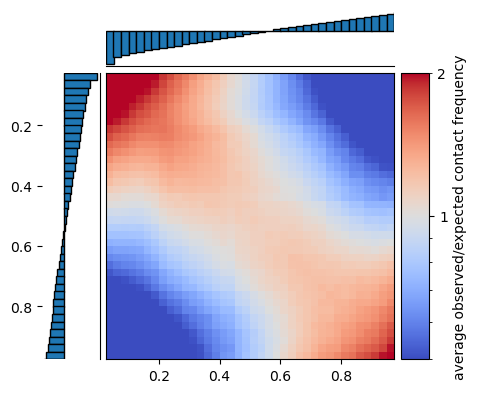

In [44]:
saddleplot(eigenvector_track_1,
           interaction_sum_1/interaction_count_1,
           N_GROUPS,
           qrange=(Q_LO,Q_HI),
           cbar_kws={'label':'average observed/expected contact frequency'}
          );

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/cooltools/lib/checks.py:550: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for name, group in track.groupby(track.columns[0]):
/tmp/ipykernel_2068874/3354468934.py:97: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupmean = track[track.columns[3]].groupby(digitized_track[digitized_track.columns[3]]).mean()


cbar


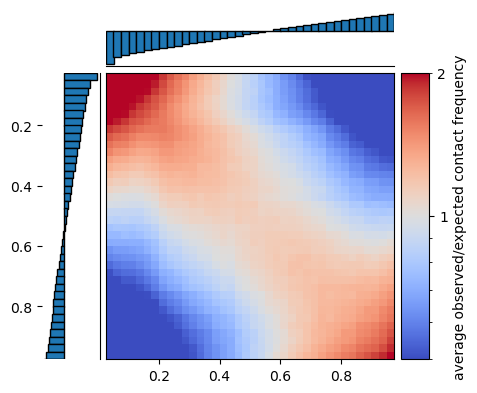

In [45]:
saddleplot(eigenvector_track_2,
           interaction_sum_2/interaction_count_2,
           N_GROUPS,
           qrange=(Q_LO,Q_HI),
           cbar_kws={'label':'average observed/expected contact frequency'}
          );

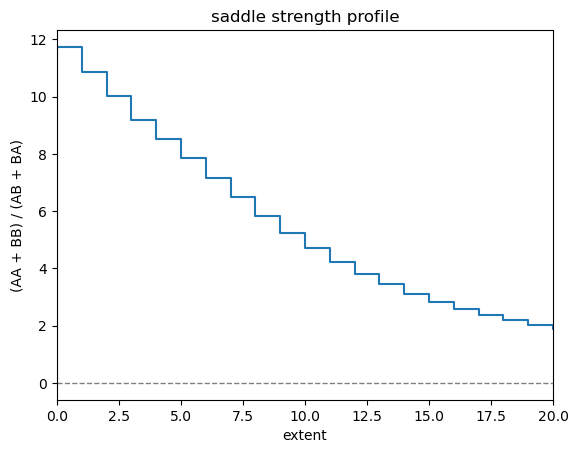

In [46]:
from cooltools.api.saddle import saddle_strength
# at extent=0, this reduces to ((S/C)[0,0] + (S/C)[-1,-1]) / (2*(S/C)[-1,0])

x = np.arange(N_GROUPS + 2)

plt.step(x, saddle_strength(interaction_sum_1, interaction_count_1), where='pre')

plt.xlabel('extent')
plt.ylabel('(AA + BB) / (AB + BA)')
plt.title('saddle strength profile')
plt.axhline(0, c='grey', ls='--', lw=1) # Q: is there a reason this is 0 not 1?
plt.xlim(0, len(x)//2); # Q: is this less intuitive than showing for all x, as it converges to no difference (i.e. 1)?

In [47]:
strength = saddle_strength(interaction_sum_1, interaction_count_1)
print(strength)

[ 0.         11.73672263 10.86022405 10.01609947  9.1709286   8.53255637
  7.84030868  7.15912874  6.48175183  5.81666434  5.22566649  4.70532601
  4.23256201  3.81147567  3.4423727   3.12045708  2.8366451   2.59008137
  2.37904781  2.1898112   2.02324547  1.87750221  1.75082972  1.64086607
  1.54482006  1.46141464  1.38905398  1.32655084  1.27220348  1.22550431
  1.18511044  1.1496469   1.11859832  1.09101309  1.06698905  1.04683446
  1.03099582  1.01877185  1.00961576  1.00332943]


In [48]:
single_strength = strength[-1]
# Canonical single value (last element)
final_strength = strength[-1]

# Mean and median across all cumulative extents
mean_strength = np.mean(strength)
median_strength = np.median(strength)

print("Final saddle strength (standard):", final_strength)
print("Mean saddle strength:", mean_strength)
print("Median saddle strength:", median_strength)

Final saddle strength (standard): 1.0033294288009496
Mean saddle strength: 3.459518151663983
Median saddle strength: 1.950373842033374


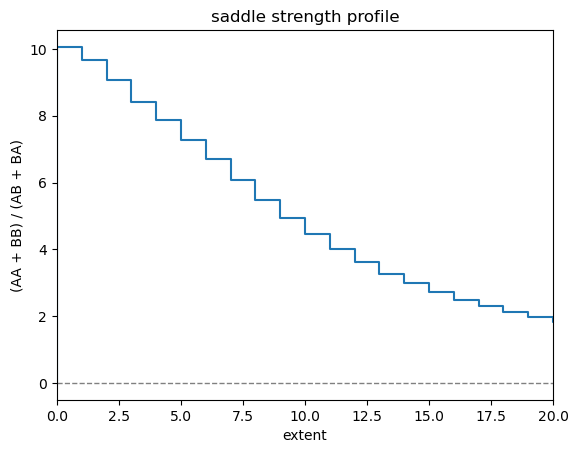

In [49]:
# at extent=0, this reduces to ((S/C)[0,0] + (S/C)[-1,-1]) / (2*(S/C)[-1,0])

x = np.arange(N_GROUPS + 2)

plt.step(x, saddle_strength(interaction_sum_2, interaction_count_2), where='pre')

plt.xlabel('extent')
plt.ylabel('(AA + BB) / (AB + BA)')
plt.title('saddle strength profile')
plt.axhline(0, c='grey', ls='--', lw=1) # Q: is there a reason this is 0 not 1?
plt.xlim(0, len(x)//2); # Q: is this less intuitive than showing for all x, as it converges to no difference (i.e. 1)?

In [50]:
strength = saddle_strength(interaction_sum_2, interaction_count_2)
print(strength)

[ 0.         10.06033593  9.65910808  9.08441392  8.40476639  7.87743897
  7.28589017  6.70223105  6.08813542  5.47671933  4.93075933  4.44431039
  4.00673872  3.61571105  3.27486316  2.97897239  2.71754384  2.49129508
  2.29661884  2.12220346  1.9672808   1.83292927  1.71449591  1.61148347
  1.52122049  1.44306555  1.37479733  1.31577897  1.26420956  1.2196482
  1.18084068  1.14664431  1.11647785  1.08933378  1.06566462  1.04579436
  1.0302193   1.01817409  1.00922666  1.00314331]


In [51]:
single_strength = strength[-1]
# Canonical single value (last element)
final_strength = strength[-1]

# Mean and median across all cumulative extents
mean_strength = np.mean(strength)
median_strength = np.median(strength)

print("Final saddle strength (standard):", final_strength)
print("Mean saddle strength:", mean_strength)
print("Median saddle strength:", median_strength)

Final saddle strength (standard): 1.0031433088422705
Mean saddle strength: 3.237212100857883
Median saddle strength: 1.900105037900171


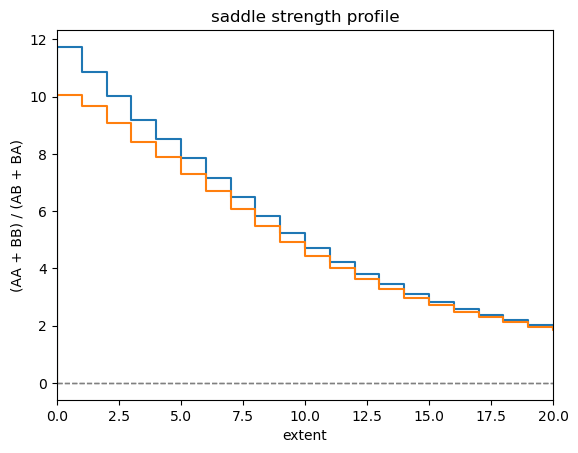

In [52]:
from cooltools.api.saddle import saddle_strength
# at extent=0, this reduces to ((S/C)[0,0] + (S/C)[-1,-1]) / (2*(S/C)[-1,0])

x = np.arange(N_GROUPS + 2)

plt.step(x, saddle_strength(interaction_sum_1, interaction_count_1), where='pre')

plt.xlabel('extent')
plt.ylabel('(AA + BB) / (AB + BA)')
plt.title('saddle strength profile')
plt.axhline(0, c='grey', ls='--', lw=1) # Q: is there a reason this is 0 not 1?
plt.xlim(0, len(x)//2); # Q: is this less intuitive than showing for all x, as it converges to no difference (i.e. 1)?

#----

# at extent=0, this reduces to ((S/C)[0,0] + (S/C)[-1,-1]) / (2*(S/C)[-1,0])

x = np.arange(N_GROUPS + 2)

plt.step(x, saddle_strength(interaction_sum_2, interaction_count_2), where='pre')

plt.xlabel('extent')
plt.ylabel('(AA + BB) / (AB + BA)')
plt.title('saddle strength profile')
plt.axhline(0, c='grey', ls='--', lw=1) # Q: is there a reason this is 0 not 1?
plt.xlim(0, len(x)//2); # Q: is this less intuitive than showing for all x, as it converges to no difference (i.e. 1)?x

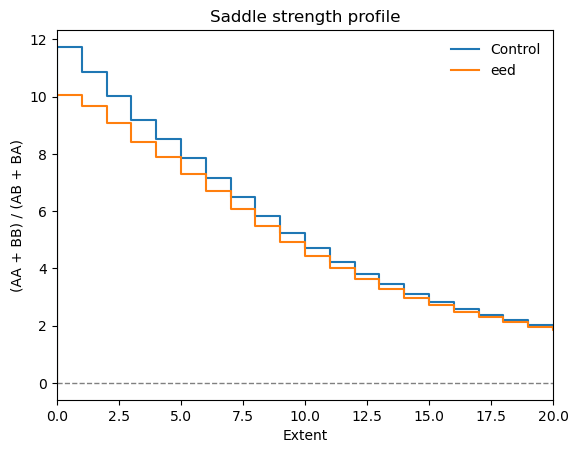

In [53]:
x = np.arange(N_GROUPS + 2)

plt.step(x, saddle_strength(interaction_sum_1, interaction_count_1), 
         where='pre', label="Control")
plt.step(x, saddle_strength(interaction_sum_2, interaction_count_2), 
         where='pre', label="eed")

plt.xlabel('Extent')
plt.ylabel('(AA + BB) / (AB + BA)')
plt.title('Saddle strength profile')

plt.axhline(0, c='grey', ls='--', lw=1)
plt.xlim(0, len(x)/2)

plt.legend(frameon=False)   # add legend
plt.show()


from cooltools.api.saddle import saddle_strength
# at extent=0, this reduces to ((S/C)[0,0] + (S/C)[-1,-1]) / (2*(S/C)[-1,0])

x = np.arange(N_GROUPS + 2)

plt.step(x, saddle_strength(interaction_sum_1, interaction_count_1), where='pre')

plt.xlabel('extent')
plt.ylabel('(AA + BB) / (AB + BA)')
plt.title('saddle strength profile')
plt.axhline(0, c='grey', ls='--', lw=1) # Q: is there a reason this is 0 not 1?
plt.xlim(0, len(x)//2); # Q: is this less intuitive than showing for all x, as it converges to no difference (i.e. 1)?

from cooltools.api.saddle import saddle_strength
# at extent=0, this reduces to ((S/C)[0,0] + (S/C)[-1,-1]) / (2*(S/C)[-1,0])

x = np.arange(N_GROUPS + 2)

plt.step(x, saddle_strength(interaction_sum_2, interaction_count_2), where='pre')

plt.xlabel('extent')
plt.ylabel('(AA + BB) / (AB + BA)')
plt.title('saddle strength profile')
plt.axhline(0, c='grey', ls='--', lw=1) # Q: is there a reason this is 0 not 1?
plt.xlim(0, len(x)//2); # Q: is this less intuitive than showing for all x, as it converges to no difference (i.e. 1)?

from cooltools.api.saddle import saddle_strength
# at extent=0, this reduces to ((S/C)[0,0] + (S/C)[-1,-1]) / (2*(S/C)[-1,0])

x = np.arange(N_GROUPS + 2)

plt.step(x, saddle_strength(interaction_sum_1, interaction_count_1), where='pre')

plt.xlabel('extent')
plt.ylabel('(AA + BB) / (AB + BA)')
plt.title('saddle strength profile')
plt.axhline(0, c='grey', ls='--', lw=1) # Q: is there a reason this is 0 not 1?
plt.xlim(0, len(x)//2); # Q: is this less intuitive than showing for all x, as it converges to no difference (i.e. 1)?

####

from cooltools.api.saddle import saddle_strength
# at extent=0, this reduces to ((S/C)[0,0] + (S/C)[-1,-1]) / (2*(S/C)[-1,0])

x = np.arange(N_GROUPS + 2)

plt.step(x, saddle_strength(interaction_sum_2, interaction_count_2), where='pre')

plt.xlabel('extent')
plt.ylabel('(AA + BB) / (AB + BA)')
plt.title('saddle strength profile')
plt.axhline(0, c='grey', ls='--', lw=1) # Q: is there a reason this is 0 not 1?
plt.xlim(0, len(x)//2); # Q: is this less intuitive than showing for all x, as it converges to no difference (i.e. 1)?

from cooltools.api.saddle import saddle_strength

strength_profile1 = saddle_strength(interaction_sum_1, interaction_count_1)
single_strength1 = strength_profile1[1]   # use index 1, not 0
print("Control saddle strength =", single_strength1)

strength_profile2 = saddle_strength(interaction_sum_2, interaction_count_2)
single_strength2 = strength_profile2[1]
print("eed mut. saddle strength =", single_strength2)

In [54]:
' the objective is getting a saddle strength numbver'

' the objective is getting a saddle strength numbver'

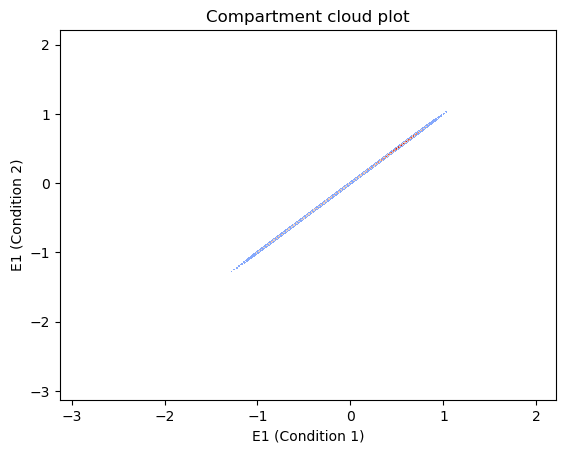

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.kdeplot(
    x=eigenvector_track_1["E1"], 
    y=eigenvector_track_2["E1"],
    fill=True, cmap="coolwarm", thresh=0.05
)
plt.xlabel("E1 (Condition 1)")
plt.ylabel("E1 (Condition 2)")
plt.title("Compartment cloud plot")
plt.show()


/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


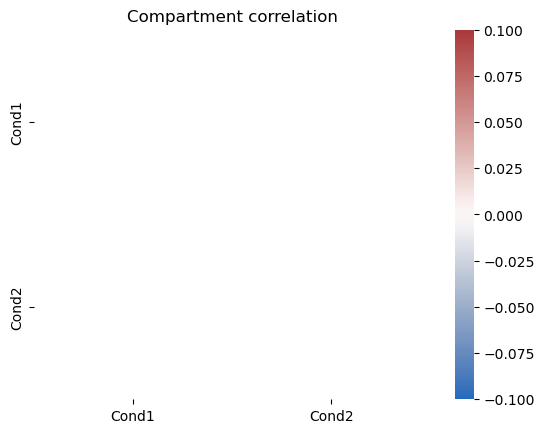

In [56]:
import numpy as np
import seaborn as sns

eigmat = np.vstack([
    eigenvector_track_1["E1"],
    eigenvector_track_2["E1"]
])

corr = np.corrcoef(eigmat)

sns.heatmap(corr, cmap="vlag", annot=True,
            xticklabels=["Cond1","Cond2"],
            yticklabels=["Cond1","Cond2"])
plt.title("Compartment correlation")
plt.show()

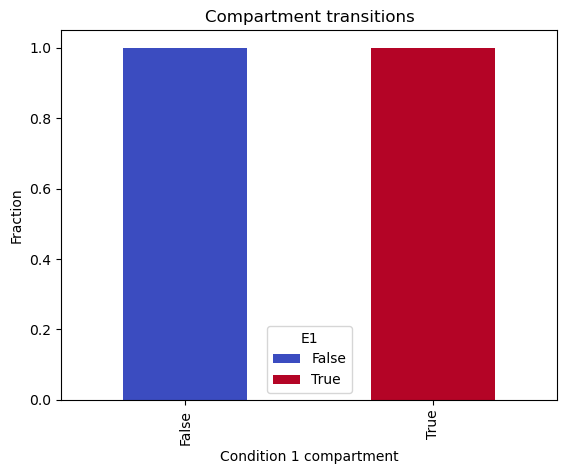

In [57]:
## compartment transition plot
import pandas as pd

labels1 = eigenvector_track_1["E1"] > 0
labels2 = eigenvector_track_2["E1"] > 0

transition = pd.crosstab(labels1, labels2, normalize="index")

transition.plot.bar(stacked=True, colormap="coolwarm")
plt.xlabel("Condition 1 compartment")
plt.ylabel("Fraction")
plt.title("Compartment transitions")
plt.show()  

In [59]:
import numpy as np

# Align orientation of eigenvectors by correlating with GC coverage
corr1 = np.corrcoef(eigenvector_track_1["E1"], gc_cov.loc[eigenvector_track_1.index, "GC"])[0,1]
corr2 = np.corrcoef(eigenvector_track_2["E1"], gc_cov.loc[eigenvector_track_2.index, "GC"])[0,1]

if corr1 < 0:
    eigenvector_track_1["E1"] *= -1
if corr2 < 0:
    eigenvector_track_2["E1"] *= -1


In [60]:
import pandas as pd

# Assign compartments: A if E1 > 0, else B
labels1 = eigenvector_track_1["E1"].gt(0).map({True: "A", False: "B"})
labels2 = eigenvector_track_2["E1"].gt(0).map({True: "A", False: "B"})

# Combine into a dataframe
df = pd.DataFrame({"cond1": labels1.values, "cond2": labels2.values})

# Build transition categories
df["transition"] = df["cond1"] + "to" + df["cond2"]

# Count frequencies
counts = df["transition"].value_counts(normalize=True) * 100

# Reformat into desired table
summary = {
    "bothA": counts.get("AtoA", 0),
    "bothB": counts.get("BtoB", 0),
    "AtoB": counts.get("AtoB", 0),
    "BtoA": counts.get("BtoA", 0),
}

summary_df = pd.DataFrame(summary, index=["%"]).T
print(summary_df)

               %
bothA  42.160386
bothB  57.839614
AtoB    0.000000
BtoA    0.000000
